# **Exercise 1**

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def G_h(z):    # hinge loss
    return np.maximum(0, 1-z)

def G_l(z):    # logistic loss
    return np.log(1 + np.exp(-z))

def G_sh(z):   # squared hinge loss
    return np.maximum(0, 1-z)**2

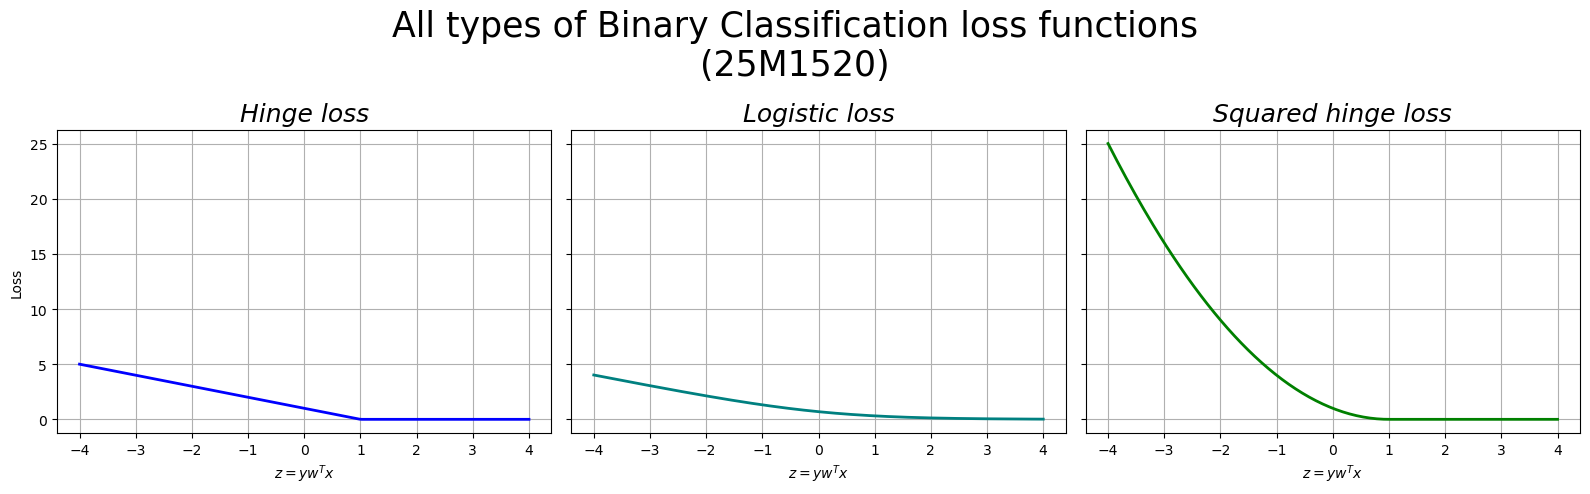

In [31]:
z = np.linspace(-4, 4, 200)     # z takes the values on the real line

losses = [
    ("Hinge loss", G_h(z)),
    ("Logistic loss", G_l(z)),
    ("Squared hinge loss", G_sh(z)),
]

colors = ["blue","teal","green"]
font = {
    "fontsize" : 18,
    "fontstyle" : "italic"
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, (title, values), color in zip(axes, losses, colors):
    ax.plot(z, values, color=color, linewidth=2)
    ax.set_title(f"{title}", fontdict=font)
    ax.set_xlabel(r"$z = y w^T x$")
    ax.grid(True)

axes[0].set_ylabel("Loss")

plt.suptitle("All types of Binary Classification loss functions\n(25M1520)", fontsize=25)
plt.tight_layout()
plt.grid(True)
plt.show()

# Comments:
1. For z ≥ 1:
   - Hinge and squared hinge losses are exactly zero (margin satisfied).
   - Logistic loss approaches zero smoothly but never becomes exactly zero.

2. For 0 < z < 1:
   - Hinge decreases linearly.
   - Squared hinge decreases quadratically (stronger penalty near margin).
   - Logistic decreases smoothly.

3. For z < 0 (misclassification):
   - Hinge grows linearly.
   - Squared hinge grows quadratically (largest penalty).
   - Logistic grows smoothly and approximately linearly.

4. Smoothness:
   - Logistic loss is smooth everywhere.
   - Hinge is non-differentiable at z = 1.
   - Squared hinge is differentiable but not twice differentiable at z = 1.

---

# **Exercise 2**

In [32]:
from sklearn.datasets import load_iris

iris = load_iris()
A = iris.data            # feature matrix
y_raw = iris.target      # original labels

In [33]:
A

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [34]:
y_raw

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [35]:
print("Data shape:", A.shape)
print("Target shape:", y_raw.shape)

Data shape: (150, 4)
Target shape: (150,)


# Question 1

In [36]:
classes, counts = np.unique(y_raw, return_counts=True)
C = len(classes)
print(f"Iris dataset contains {C} classes with labels {classes}")

for c, cnt in zip(classes, counts):
    print(f"Class {c}: {cnt} samples")

Iris dataset contains 3 classes with labels [0 1 2]
Class 0: 50 samples
Class 1: 50 samples
Class 2: 50 samples


# Question 2

In [37]:
# binary classification - One-vs-Rest mode (OvR mode)
# Converting labels to {+1, -1}

y = np.ones(y_raw.shape, dtype="int")   # initialize all to +1
y[y_raw!=1] = -1                        # classes 0,2,3,...,C-1 -> -1

print("Original labels:", np.unique(y_raw))
print("Converted labels:", np.unique(y))

Original labels: [0 1 2]
Converted labels: [-1  1]


In [38]:
y

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [39]:
classes, counts = np.unique(y, return_counts=True)
C = len(classes)
print(f"Updated Iris dataset contains {C} classes with labels {classes}")

for c, cnt in zip(classes, counts):
    print(f"Class {c}: {cnt} samples")

Updated Iris dataset contains 2 classes with labels [-1  1]
Class -1: 100 samples
Class 1: 50 samples


# Question 3

In [40]:
n,d  = A.shape
indexarr = np.arange(n)
np.random.shuffle(indexarr)
print(indexarr)

[ 76   7  39   3  36  93  82  89  23 128  54  13  45 111 134 147 117  70
 125  18 129  10 146  90  56  95  22 103 100   4  57 102  26  74  32  47
  79 136  96  68  25 143  27 126  44 109 122  51  99  50 120 106 101  42
 119  92  12 116  29 132  94  34  53 148  28  37  49  11  19  78  64  73
   8 123 124  88  16  21  75  62  46  58 140   5  91 104 149  71  65  59
 145  55 133 127  17 131  87  60  35 135  84  98  86  52 118  20  66 115
 113  72  61  81 137 142  77  48  67  63 121  24   0 144 114 139  15  85
 110  38 138  30   1  14  33  97   6 130 141 112 107  69  80  41   9   2
  31  83  43 108 105  40]


In [41]:
# first 80% training data, rest 20% testing data
split = int(0.8 * n)
train_idx = indexarr[:split]
test_idx  = indexarr[split:]

train_data  = A[train_idx]
train_label = y[train_idx]
test_data   = A[test_idx]
test_label  = y[test_idx]

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (120, 4)
Test data shape: (30, 4)


# Question 4

In [42]:
def predict(w, x):
    return np.sign(np.dot(w, x))

# Question 5

In [43]:
def compute_accuracy(data, labels, model_w):
    n = data.shape[0]

    correct = 0
    for i in range(n):
        if predict(model_w, data[i]) == labels[i]:
            correct += 1
    return correct / n

---

# **Exercise 3**

# Question 1

We choose hinge loss 
$$
f_i(w) = \frac{\lambda}{2} \|w\|^2 + \frac{1}{n} \sum_{i=1}^{n} L_h(y_i, w^T x_i)
$$

# Question 2

In [44]:
def hinge_loss(y, z):
    return np.maximum(0, 1-y*z)

# Question 3

In [45]:
def objective_value_hinge(w, data, labels, lambda_):
    n = data.shape[0]
    reg = (lambda_/2) * np.dot(w, w)

    loss = 0.0
    for i in range(n):
        loss += hinge_loss(labels[i], np.dot(w, data[i]))
    return reg + loss / n

# Question 4

Subgradient for hinge loss:
$$
g_i(w) = \nabla f_i(w) = \begin{cases} 
\lambda w - y_i x_i & \text{if } y_i w^T x_i < 1 \\ 
\lambda w & \text{otherwise} 
\end{cases}
$$

In [46]:
def subgradient_hinge(w, x_i, y_i, lambda_):
    if y_i * np.dot(w, x_i) < 1:
        return lambda_*w - y_i*x_i
    else:
        return lambda_*w

# Question 5

In [47]:
def OPT1(data, label, test_data, test_label, lambda_, num_epochs=1000):
    n, d = data.shape
    w = np.zeros(d)     # initialize w
    t = 1               # step size regulator
    arr = np.arange(n)

    obj_vals, train_accs, test_accs = [], [], []

    for _ in range(num_epochs):
        np.random.shuffle(arr)
        for i in arr:
            step = 1 / t
            w -= step*subgradient_hinge(w, data[i], label[i], lambda_)
            t += 1
            if t > 1e4:     # reset to avoid vanishing step
                t = 1

        # store metrics per epoch
        obj_vals.append(objective_value_hinge(w, data, label, lambda_))
        train_accs.append(compute_accuracy(data, label, w))
        test_accs.append(compute_accuracy(test_data, test_label, w))

    return obj_vals, train_accs, test_accs

# Question 6

In [48]:
lambdas = [1e-3, 1e-2, 0.1, 1, 10]

train_accs, test_accs, obj_vals = {}, {}, {}

for lambda_ in lambdas:
    obj_vals[lambda_], train_accs[lambda_], test_accs[lambda_] = OPT1(
        train_data, train_label, 
        test_data, test_label, 
        lambda_
    )

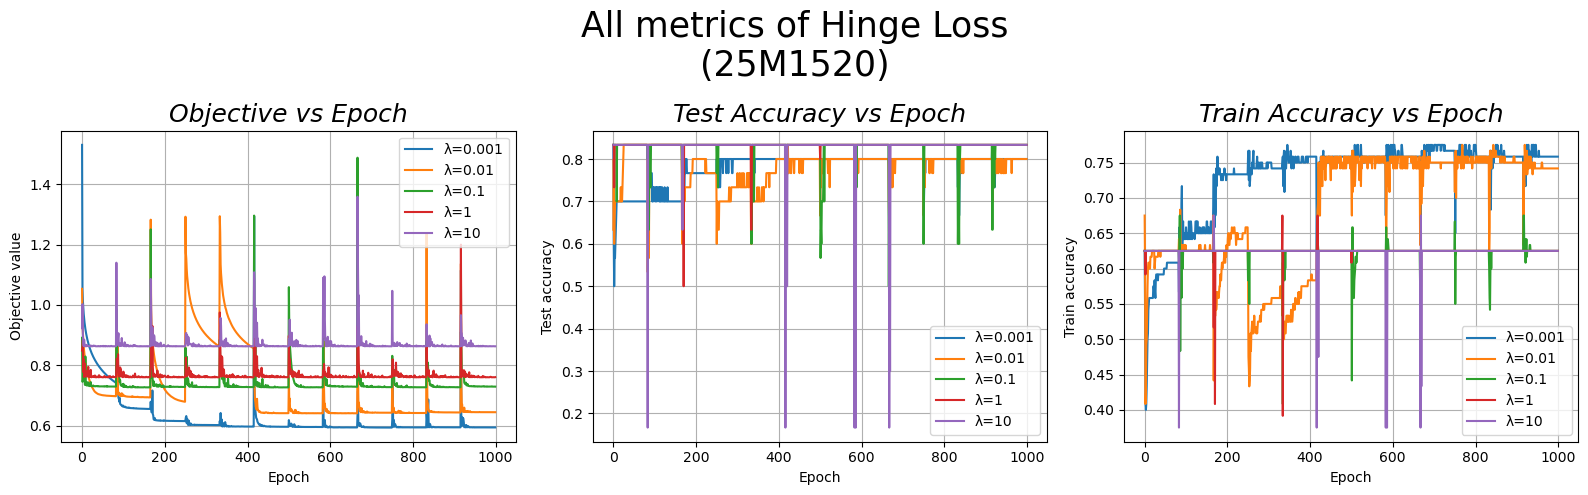

In [49]:
plots = [
    (obj_vals, "Objective value", "Objective vs Epoch"),
    (test_accs, "Test accuracy", "Test Accuracy vs Epoch"),
    (train_accs, "Train accuracy", "Train Accuracy vs Epoch")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for ax, (values, ylabel, title) in zip(axes, plots):
    for lambda_ in lambdas:
        ax.plot(values[lambda_], label=f"λ={lambda_}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title}", fontdict=font)
    ax.legend()
    ax.grid(True)

plt.suptitle("All metrics of Hinge Loss\n(25M1520)", fontsize=25)
plt.tight_layout()
plt.show()

In [50]:
# Tabulation for the final test set accuracy and train set accuracy for each λ value
print("λ\tTrain Acc\tTest Acc")
for lambda_ in lambdas:
    final_train_acc = train_accs[lambda_][-1]
    final_test_acc = test_accs[lambda_][-1]

    print(f"{lambda_}\t{final_train_acc:.3f}\t\t{final_test_acc:.3f}")

λ	Train Acc	Test Acc
0.001	0.758		0.800
0.01	0.742		0.800
0.1	0.625		0.833
1	0.625		0.833
10	0.625		0.833


## Effect of $\lambda$ on the objective function
* For **small values of $\lambda$ ($10^{-3}, 10^{-2}$)**, the regularization term is weak.
    * The objective value decreases rapidly in early epochs.
    * The learned model may **overfit** the training data.
* For **moderate $\lambda$ ($0.1, 1$)**:
    * The objective decreases smoothly and stabilizes.
    * A good balance between data fitting and regularization is achieved.
* For **large $\lambda$ ($10$)**:
    * The regularization term dominates.
    * The objective decreases slowly and converges to a higher value.
    * The learned weight vector has a small norm.

## Effect of $\lambda$ on training accuracy
* **Small $\lambda$** leads to **high training accuracy**, since the model focuses more on minimizing hinge loss.
* **Large $\lambda$** results in **lower training accuracy**, as strong regularization restricts model complexity.

## Effect of $\lambda$ on test accuracy
* **Very small $\lambda$** can cause overfitting, leading to lower test accuracy despite high training accuracy.
* **Moderate $\lambda$ (typically $0.1$ or $1$)** yields the **best test accuracy**, indicating good generalization.
* **Very large $\lambda$** underfits the data, reducing both training and test accuracy.

# Question 7

In [51]:
def logistic_loss(y, z):
    return np.log(1 + np.exp(-y*z))

def objective_value_logistic(w, data, labels, lambda_):
    n = data.shape[0]
    reg = (lambda_/2) * np.dot(w, w)
    loss = 0.0
    for i in range(n):
        loss += logistic_loss(labels[i], np.dot(w, data[i]))
    return reg + loss / n

def subgradient_logistic(w, x_i, y_i, lambda_):
    z = y_i * np.dot(w, x_i)
    return lambda_ * w - (y_i * x_i) / (1 + np.exp(z))

In [52]:
def squared_hinge_loss(y, z):
    return np.maximum(0, 1 - y*z)**2

def objective_value_squared_hinge(w, data, labels, lambda_):
    n = data.shape[0]
    reg = (lambda_/2) * np.dot(w, w)

    loss = 0.0
    for i in range(n):
        loss += squared_hinge_loss(labels[i], np.dot(w, data[i]))
    return reg + loss / n

def subgradient_squared_hinge(w, x_i, y_i, lambda_):
    margin = 1 - y_i * np.dot(w, x_i)
    if margin > 0:
        return lambda_ * w - 2 * margin * y_i * x_i
    else:
        return lambda_ * w

In [53]:

def OPT1_early_stop(data, label, test_data, test_label, lambda_, loss_type="hinge" ,num_epochs=1000, patience=20):
    n, d = data.shape
    w = np.zeros(d)      # initialize w
    t = 1                # step size regulator
    arr = np.arange(n)

    obj_vals, train_accs, test_accs = [], [], []

    best_acc = 0.0
    wait = 0

    for _ in range(num_epochs):
        np.random.shuffle(arr)
        for i in arr:
            step = 1 / t
        
            match loss_type:
                case "hinge": w -= step * subgradient_hinge(w, data[i], label[i], lambda_)
                case "logistic": w -= step * subgradient_logistic(w, data[i], label[i], lambda_)
                case "squared_hinge": w -= step * subgradient_squared_hinge(w, data[i], label[i], lambda_)
                case _: raise ValueError("loss_type must be hinge, logistic, squared_hinge !!")
                
            t += 1
            if t > 1e4:     # reset to avoid vanishing step
                t = 1

        # store metrics per epoch
        match loss_type:
            case "hinge": obj = objective_value_hinge(w, data, label, lambda_)
            case "logistic": obj = objective_value_logistic(w, data, label, lambda_)
            case "squared_hinge": obj = objective_value_squared_hinge(w, data, label, lambda_)
            case _: raise ValueError("loss_type must be hinge, logistic, squared_hinge !!")
        
        train_acc = compute_accuracy(data, label, w)
        test_acc = compute_accuracy(test_data, test_label, w)

        obj_vals.append(obj)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # early stopping based on test accuracy
        if test_acc > best_acc:
            best_acc = test_acc
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    return obj_vals, train_accs, test_accs


# Question 8

In [54]:
lambdas = [1e-3, 1e-2, 0.1, 1, 10]
num_epochs = 1000
patience = 20

results = {
    "hinge": {},
    "logistic": {},
    "squared_hinge": {}
}

for loss_type in results:
    for lambda_ in lambdas:
        obj_vals, train_accs, test_accs = OPT1_early_stop(
            train_data, train_label,
            test_data, test_label,
            lambda_,
            loss_type=loss_type,
            num_epochs=num_epochs,
            patience=patience
        )

        results[loss_type][lambda_] = {
            "obj": obj_vals,
            "train_acc": train_accs,
            "test_acc": test_accs
        }


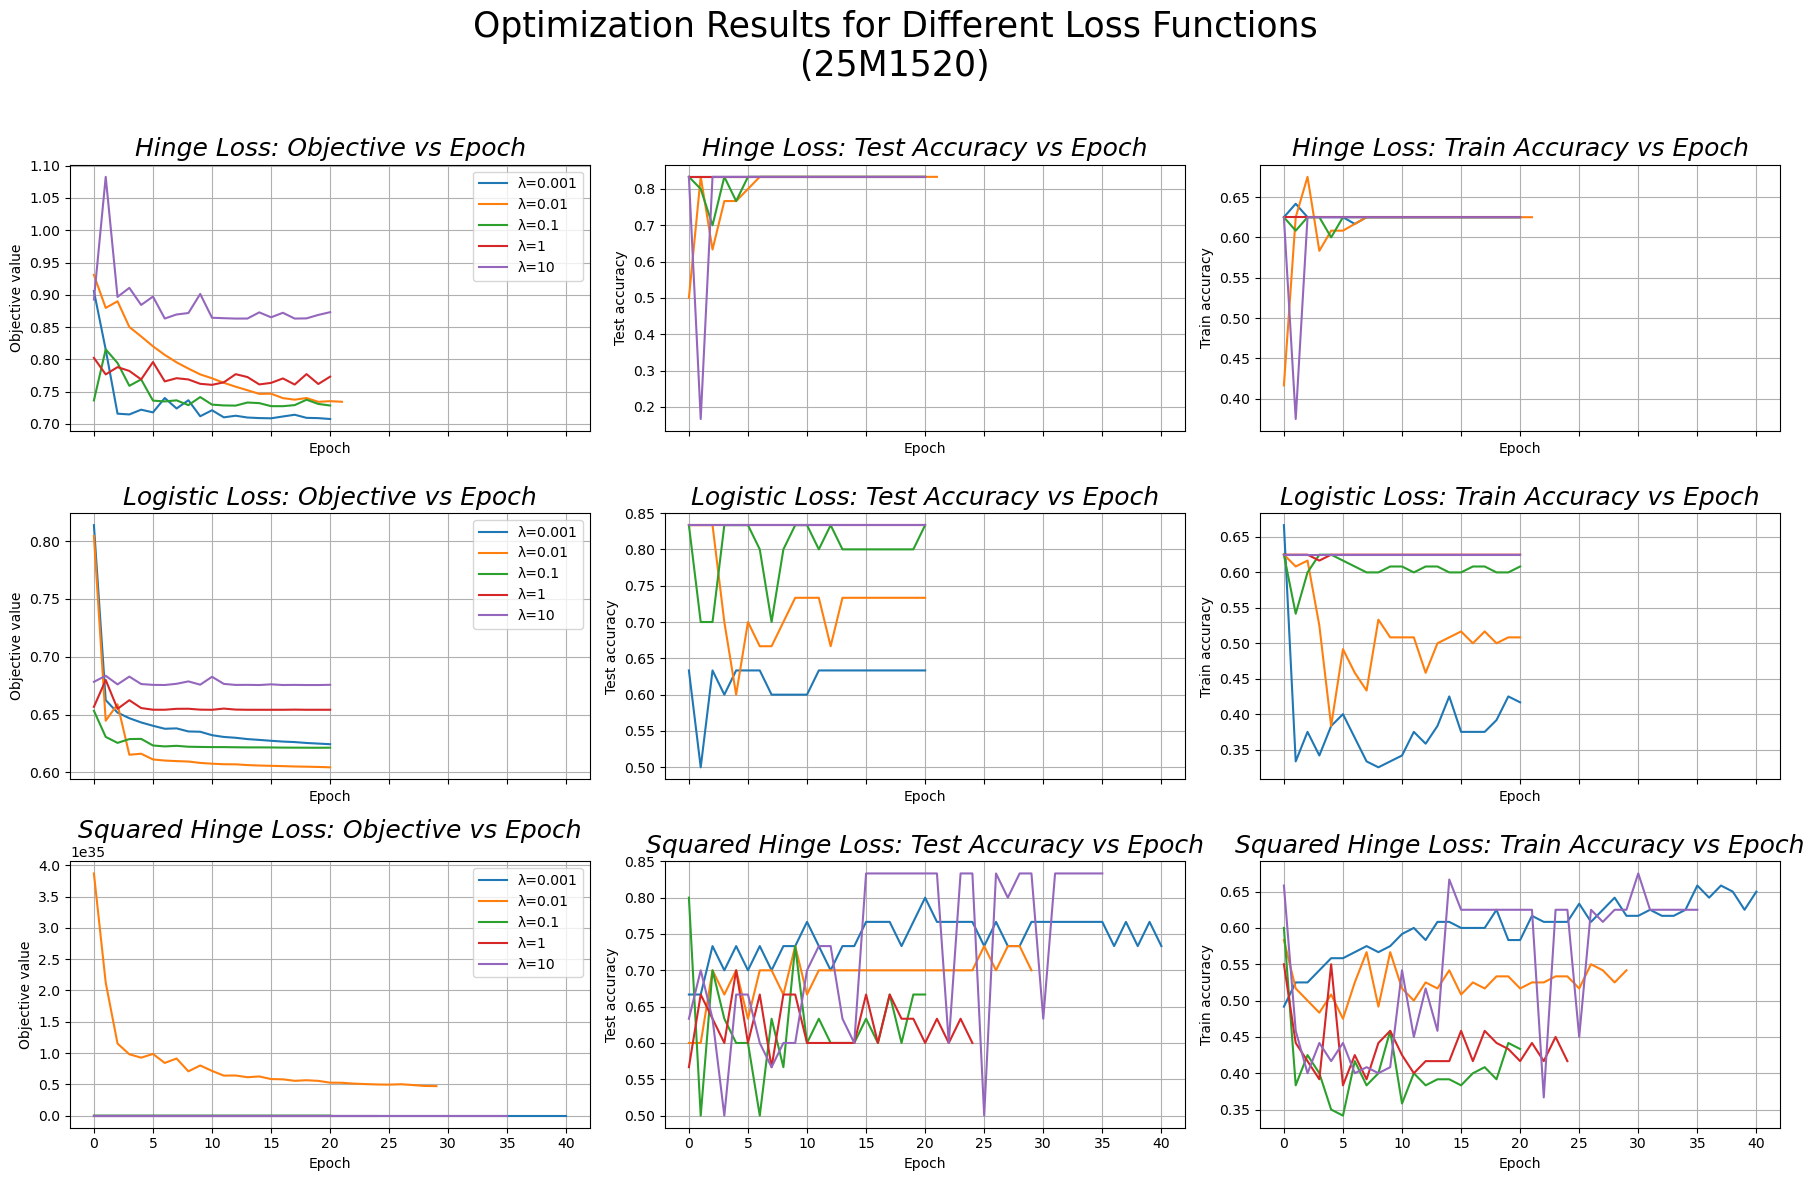

In [55]:
loss_names = {
    "hinge": "Hinge Loss",
    "logistic": "Logistic Loss",
    "squared_hinge": "Squared Hinge Loss"
}

plots = [
    ("obj", "Objective value", "Objective vs Epoch"),
    ("test_acc", "Test accuracy", "Test Accuracy vs Epoch"),
    ("train_acc", "Train accuracy", "Train Accuracy vs Epoch")
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for row, (loss_type, loss_title) in enumerate(loss_names.items()):
    for col, (key, ylabel, title) in enumerate(plots):
        ax = axes[row, col]

        for lambda_ in lambdas:
            ax.plot(
                results[loss_type][lambda_][key],
                label=f"λ={lambda_}"
            )

        ax.set_title(f"{loss_title}: {title}", fontdict=font)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True)

        # show legend only in the first subplot of each row
        if col == 0:
            ax.legend()

plt.suptitle("Optimization Results for Different Loss Functions\n(25M1520)", fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [56]:
for loss_type, loss_title in loss_names.items():
    print(f"\n{loss_title}")
    print("λ\tTrain Acc\tTest Acc")

    for lambda_ in lambdas:
        tr = results[loss_type][lambda_]["train_acc"][-1]
        te = results[loss_type][lambda_]["test_acc"][-1]
        print(f"{lambda_}\t{tr:.3f}\t\t{te:.3f}")


Hinge Loss
λ	Train Acc	Test Acc
0.001	0.625		0.833
0.01	0.625		0.833
0.1	0.625		0.833
1	0.625		0.833
10	0.625		0.833

Logistic Loss
λ	Train Acc	Test Acc
0.001	0.417		0.633
0.01	0.508		0.733
0.1	0.608		0.833
1	0.625		0.833
10	0.625		0.833

Squared Hinge Loss
λ	Train Acc	Test Acc
0.001	0.650		0.733
0.01	0.542		0.700
0.1	0.433		0.667
1	0.417		0.600
10	0.625		0.833


# **Comparison of Loss Functions**
# *Logistic Loss*
* The objective value decreases smoothly due to its differentiable nature.
* Accuracies increase gradually and remain stable.
* Shows better generalization and is less sensitive to $\lambda$.
# *Squared hinge Loss*
* The objective value drops faster initially due to stronger penalization of margin violations.
* Test accuracy may peak early and then decrease, showing a tendency to overfit.
* More sensitive to $\lambda$ and benefits significantly from early stopping.
# *Effect of Early Stopping*
* Prevents overfitting for both loss types.
* Reduces computational cost by eliminating unnecessary epochs.
* Has a greater impact on squared hinge loss due to its aggressive update style.

---